In [ ]:
# Step 1: Test the notebook works
import pandas as pd
print("Notebook is working")

Notebook is working


In [ ]:
#Step 1: Load the transaction and identity files
import pandas as pd

train_transaction = pd.read_csv("../data/raw/train_transaction.csv")
train_identity = pd.read_csv("../data/raw/train_identity.csv")

print("train_transaction shape:", train_transaction.shape)
print("train_identity shape:", train_identity.shape)

train_transaction shape: (590540, 394)
train_identity shape: (144233, 41)


In [4]:
#Step 2: Look at the columns
train_transaction.columns.tolist()[:20]

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'P_emaildomain',
 'R_emaildomain',
 'C1',
 'C2',
 'C3']

In [5]:
#Step 3: Check the target variable (most important cell)
train_transaction['isFraud'].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [6]:
train_transaction['isFraud'].value_counts(normalize=True) * 100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

In [7]:
#Step 4: Merge transaction + identity
train = train_transaction.merge(train_identity, on="TransactionID", how="left")
print("Merged shape:", train.shape)

Merged shape: (590540, 434)


In [8]:
#Step 5: Check missing data
missing = train.isnull().mean().sort_values(ascending=False) * 100
missing.head(20)

id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
id_09    87.312290
dtype: float64

In [9]:
#Step 6: Check data types and the critical TransactionDT column
train['TransactionDT'].describe()

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

In [10]:
train.dtypes.value_counts()

float64    399
object      31
int64        4
Name: count, dtype: int64

In [11]:
train.select_dtypes(include='object').columns.tolist()

['ProductCD',
 'card4',
 'card6',
 'P_emaildomain',
 'R_emaildomain',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'id_12',
 'id_15',
 'id_16',
 'id_23',
 'id_27',
 'id_28',
 'id_29',
 'id_30',
 'id_31',
 'id_33',
 'id_34',
 'id_35',
 'id_36',
 'id_37',
 'id_38',
 'DeviceType',
 'DeviceInfo']

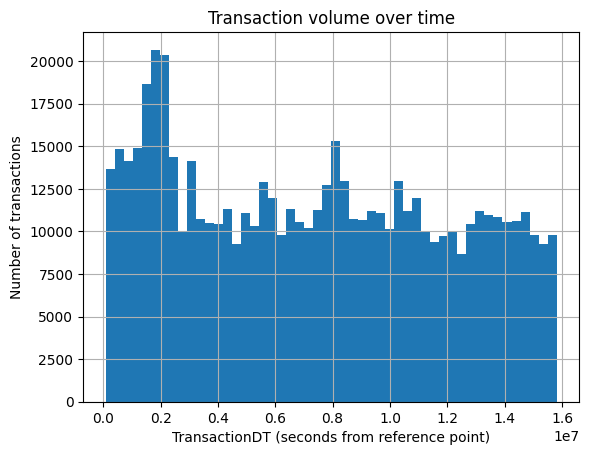

In [12]:
#Step 7: Visualize the time range (this justifies your time-based split)
import matplotlib.pyplot as plt

train['TransactionDT'].hist(bins=50)
plt.xlabel("TransactionDT (seconds from reference point)")
plt.ylabel("Number of transactions")
plt.title("Transaction volume over time")
plt.show()

In [13]:
#Step 9: Test it from your notebook
import sys
sys.path.append("../src")

from data_loader import load_raw_data, time_based_split

data = load_raw_data()
train_df, test_df = time_based_split(data)

Train range: 86400 to 12192842
Test range:  12192900 to 15811131
Train shape: (472432, 434), Test shape: (118108, 434)
Train fraud rate: 3.51%
Test fraud rate:  3.44%
